In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from scipy.stats import chi2, kstest, skew, kurtosis
import time

from ppca import ppca_em, ppca_reconstruct_matrix, ppca_reconstruct_optimal
from random_nans import random_nans
from inject_random_missing_two_modes import inject_random_missing_two_modes
from select_retained_nPC import select_retained_nPC

from thresholds import (
    compute_residual_statistic,
    fit_thresholds,
    detect_with_thresholds,
    single_sample_stat_and_threshold
)

# 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
def standardize(df_like, means, stds):
    return (df_like - means) / stds


def transform_SNR(X, b=0.0, random_state=None):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=float)
    rms_cols = np.sqrt(np.nanmean(X**2, axis=0))
    noise = b * rms_cols * rng.normal(0, 1, size=X.shape)
    return np.where(np.isnan(X), np.nan, X + noise)


def missing_pattern(X, method="MCAR", fraction=0.2, random_state=42):
    if method == "MCAR":
        return random_nans(X.copy(), fraction=fraction, random_state=random_state)
    elif method == "mode_selected":
        return inject_random_missing_two_modes(X.copy(), fraction=fraction, random_state=random_state)
    else:
        raise ValueError("method must be 'MCAR' or 'mode_selected'")


def ppca_full_reconstruct(X_missing, W, sigma2, mu=None, return_latent=False, method='optimal'):
    if mu is None:
        mu = np.zeros(X_missing.shape[1])
    return ppca_reconstruct_matrix(
        X_missing, W, sigma2, mu, method=method, return_latent=return_latent
    )

In [7]:
path = 'data/df_result(Quasi-linear,0.9,simply-supported,6).csv'     # 'data/df_result(Quai-linear,0.9,6).csv'
X = pd.read_csv(path, encoding='utf-8')

n_repeat = 20
fraction = 0.3
n_train = 200
n_damaged = 320
b = 0.001

missing_method = "MCAR"
recon_method = "optimal"       # 'optimal' or 'latent_mean'
statistic_mode = "rspe"            # 'rspe' or 'spe'
threshold_method = "scaled_chi2"           # 'scaled_chi2', 'empirical', 'evt', 'conformal'
alphas = (0.95, 0.99)

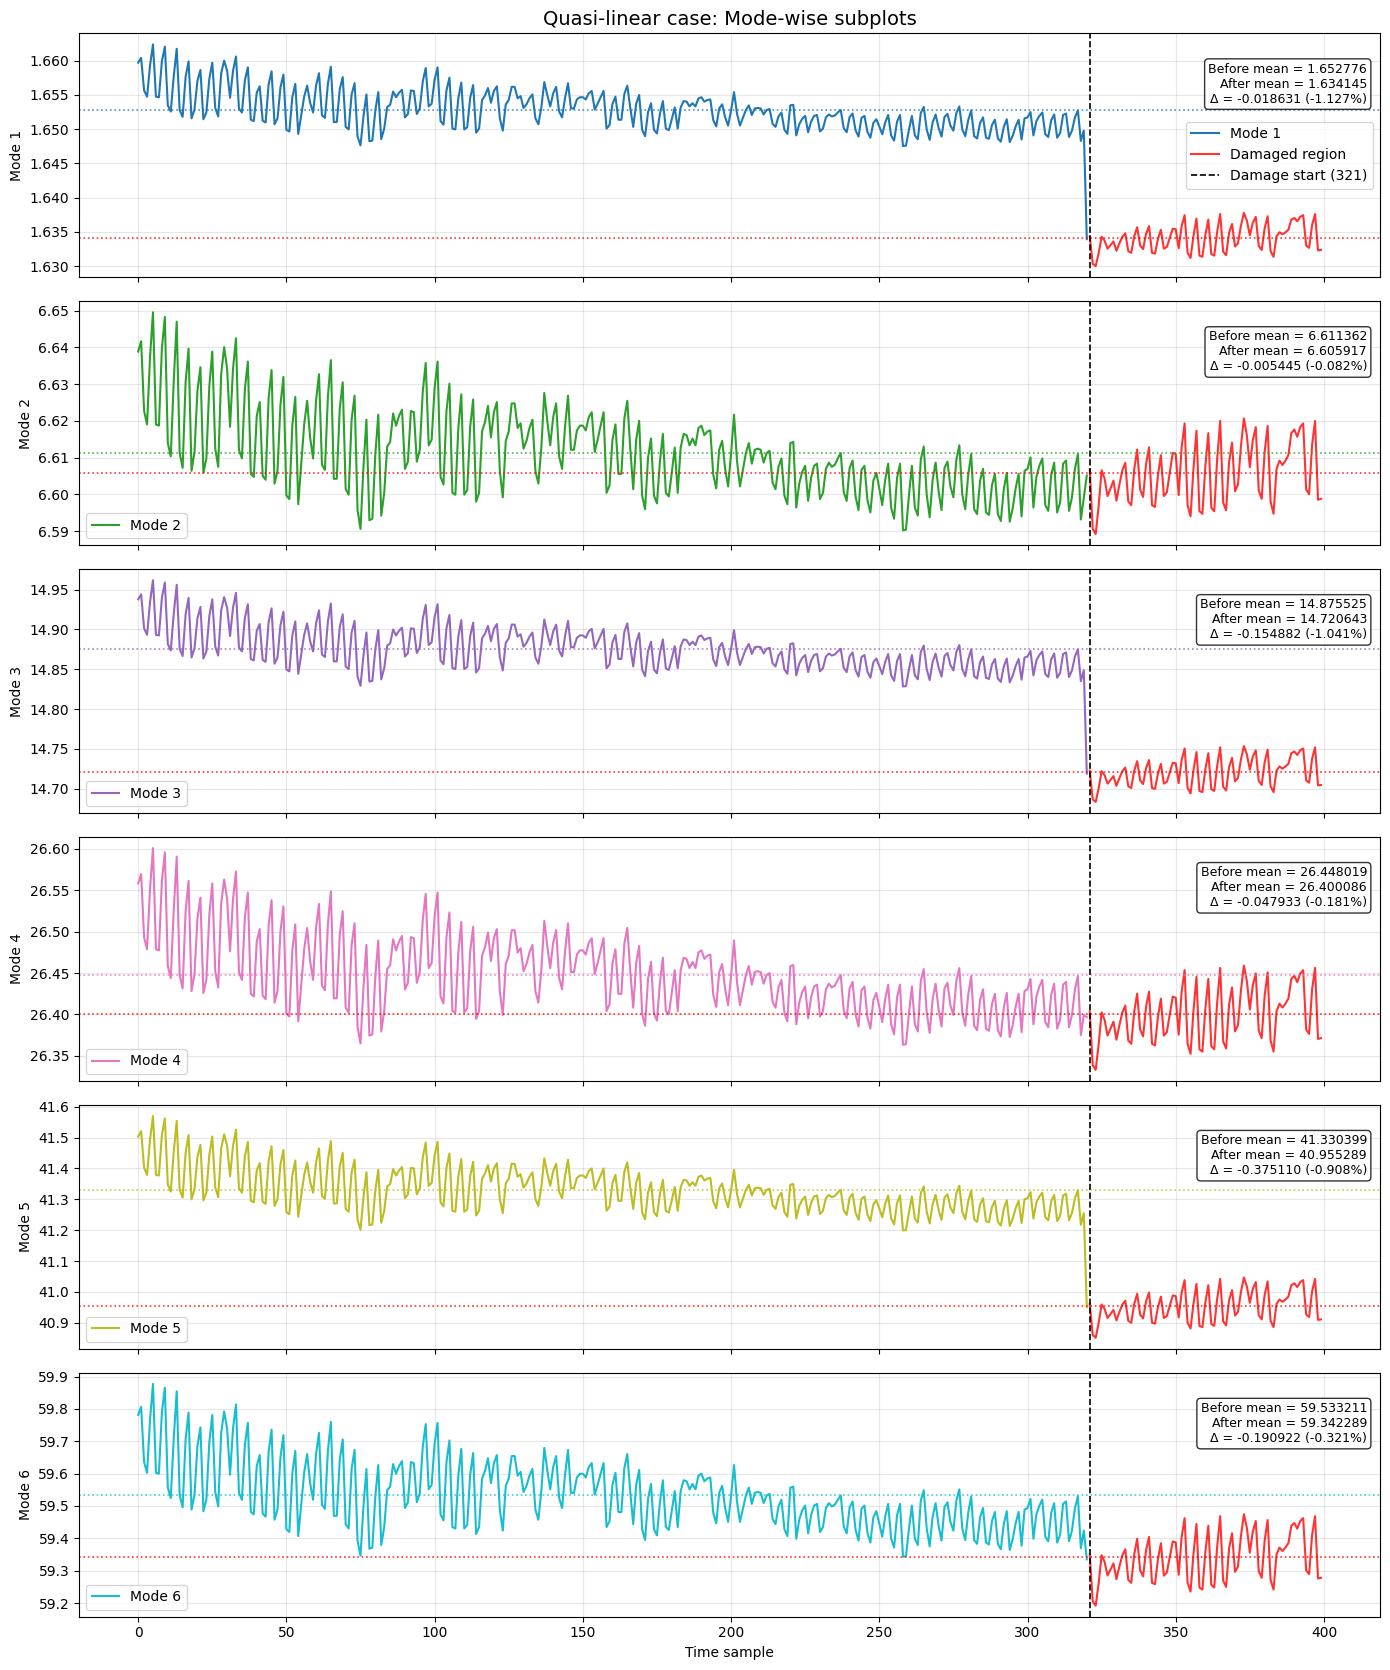